## 4.4 시계열 데이터 다루기
테이블의 모든 행은 다른 행과 독립적이었으며 행의 순서는 중요하지 않았다.

어떤 행이 앞에 있고 또 뒤에 있는지에 대한 정보를 인코딩한 열은 없었다.

시간대별 열이 있었다면 어땠을까? "2011~2012 캐피탈 바이크 쉐어 공유 자전거 데이터셋"으로 시계열 데이터를 다뤄보자.

## 4.4.1 시간 차원 더하기
소스 데이터에서 각 행은 시간별로 분리된 데이터로. 시간 행으로 되어 있는 구성을 바꿔 인덱스를 올릴 때마다

일자가 바뀌고 또 다른 축에서는 하루의 시간을 표현. 나머지 축에는 데이터의 각 열에 해당하는 날씨와 기온 등 데이터 포함

In [1]:
import numpy as np
import torch
torch.set_printoptions(edgeitems=2, threshold=50)

In [2]:
# 데이터 읽기
bikes_numpy = np.loadtxt(
    "/content/hour-fixed.csv",
    dtype=np.float32,
    delimiter=",",
    skiprows=1,
    converters={1: lambda x: float(x[8:10])})
bikes = torch.from_numpy(bikes_numpy)
bikes

tensor([[1.0000e+00, 1.0000e+00,  ..., 1.3000e+01, 1.6000e+01],
        [2.0000e+00, 1.0000e+00,  ..., 3.2000e+01, 4.0000e+01],
        ...,
        [1.7378e+04, 3.1000e+01,  ..., 4.8000e+01, 6.1000e+01],
        [1.7379e+04, 3.1000e+01,  ..., 3.7000e+01, 4.9000e+01]])

### 매 시간대별 데이터셋 정보
- 레코드 인덱스: instant
- 일자: day
- 계절: season(1:봄, 2:여름, 3:가을, 4:겨울)
- 연도: yr(0:2011, 1:2012)
- 월: mnth(1~12)
- 시간: hr(0~23)
- 공휴일 상태: holiday
- 요일: weekday
- 평일 상태: workingday
- 날씨 상태: weathersit(1:맑음, 2:안개, 3:약한비/눈, 4:강한비/눈)
- 섭씨 기온: temp
- 체감 섭씨 기온: atemp
- 습도: hum
- 풍속: windspeed
- 일반 사용자: casual
- 등록 사용자: registered
- 대여 자전거 수: cnt

이와 같이 시계열 데이터셋에서 각 행은 연속적인 시간상에서의 한 지점을 표현.

각 행이 순서대로 나열되며 만들어진 차원이 존재. 몇시에 몇대의 자전거를 대여했는지 예측

순서있는 데이터는 시간에 따른 데이터 사이의 관계를 분석할 수 있음

이 신경망 모델은 데이터셋을 고정된 크기로 처리하고 대여 수나 하루 중 시각, 혹은 기온이나 날씨 상태 등의 각기 다른 값에 대해 연속으로 여러 개의 값을 볼 필요가 있다. 크기가 C인 N개의 병렬 시퀀스로 표현이 가능하다.

C는 신경망 용어로 채널(1차원 데이터를 위한 열과 동일), N차원은 시간 축을 표현(한 차원당 한 시간)

## 4.4.2 시간 단위로 데이터 만들기
길이가 L인 C개의 시퀀스를 가지는 N(샘플 수)개의 컬렉션 획득(3차원 텐서(NxCxL))
- C: 17개 채널
- L: 24(1을 한시간 기준)

자전거 데이터셋에서 첫 열은 전역 레벨로 순서를 나타내는 인덱스, 두 번째는 일자, 여섯 번째는 하루 중 시각 열

데이터셋 정렬이 안되어 있다면 `torch.sort`로 정렬

In [3]:
# 일별로 매 시간 데이터셋을 구하기 위해 동일 텐서로 24시간 배치로 바라보는 뷰 필요.
# bikes 텐서의 차원 정보(shape)와 스트라이드(stride) 확인
bikes.shape, bikes.stride()

(torch.Size([17520, 17]), (17, 1))

In [4]:
# 17520시간에 17개 열이므로 일자, 시간, 17개 열의 세 개 축으로 만들기
daily_bikes = bikes.view(-1, 24, bikes.shape[1])
daily_bikes.shape, daily_bikes.stride()

(torch.Size([730, 24, 17]), (408, 17, 1))

bikes.shape[1]은 bikes 텐서의 열의 개수로 17.
- view 호출에는 새로 받을 텐서가 가질 차원 정보를 넘겨줘야 함.
- -1은 '남은 차원과 거기에 들어있는 요소를 다 합친 것'을 의미하는 플레이스홀더(placeholder)

"저장공간은?" 연속된 숫자를 저장하는 컨테이너(기반 부동소수점).

bike 텐서의 저장 공간에는 각 행이 순서대로 들어있음.(bikes.stride()를 호출해 확인)
- 가장 오른쪽 차원은 원래 데이터셋에서와 같이 열의 수가 됨.
- 가운데 차원은 연속된 24시간을 나타내는 시간 차원
- C개의 채널을 가진 하루를 L시간으로 나눈 N개의 연속된 값을 가진다고 볼 때, NxCxL 순서로 놓고 싶다면 텐서를 전치해야 함

In [5]:
daily_bikes = daily_bikes.transpose(1, 2)
daily_bikes.shape, daily_bikes.stride()

(torch.Size([730, 17, 24]), (408, 1, 17))

## 4.4.3 훈련 준비
### '날씨 상태'를 나타내는 데이터는 순서값
weathersit(1:맑음, 2:안개, 3:약한비/눈, 4:강한비/눈)

1은 좋은 날씨 4는 안좋은 날씨-> 카테고리로 간주해 각 단계를 레이블로 볼 수 있고 동시에 연속값으로 보자.

카테고리로 보려면? 값을 원핫 인코딩 벡터로 만들어 데이터셋과 병합해야함

In [6]:
# (하루 시간대 만틈의 행과 날씨 상태 가짓수 만큼의 열을 가진, 0으로 채워진 행렬 초기화)
first_day = bikes[:24].long()
weather_onehot = torch.zeros(first_day.shape[0], 4)
first_day[:,9]

tensor([1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2])

In [7]:
# 날씨 수준에 따라 행렬을 원핫 인코딩(scatter_)으로 변환.
# Unsqueeze 사용해 싱글톤 차원 더하기
weather_onehot.scatter_(
    dim=1,
    index=first_day[:,9].unsqueeze(1).long() - 1, # 날씨값은 1~4지만, 색인은 0에서 시작하므로 1을 뺌
    value=1.0)

tensor([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        ...,
        [0., 1., 0., 0.],
        [0., 1., 0., 0.]])

In [8]:
# 만들어진 행렬을 원해 데이터셋에 cat 함수를 사용하여 병합.
torch.cat((bikes[:24], weather_onehot), 1)[:1]

tensor([[ 1.0000,  1.0000,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  6.0000,
          0.0000,  1.0000,  0.2400,  0.2879,  0.8100,  0.0000,  3.0000, 13.0000,
         16.0000,  1.0000,  0.0000,  0.0000,  0.0000]])

지금까지 bikes 데이터셋에 '날씨 상태'를 원핫 인코딩하여 데이터 열이 있는 차원을 따라 병합했다.

두개 데이터셋 열이 겹겹히 쌓이게 됐다고 볼 수 있다(원래 데이터셋 뒤에 새로운 원핫 인코딩 열이 붙었음)

이어서 daily_bikes 텐성에 대해서 동일한 작업
- (B,C,L) 형태. L=24
- 값:0


In [10]:
daily_weather_onehot = torch.zeros(daily_bikes.shape[0], 4, daily_bikes.shape[2])
daily_weather_onehot.shape

torch.Size([730, 4, 24])

In [12]:
# 텐서의 C 차원에 원핫 인코딩 늘어놓기
daily_weather_onehot.scatter_(
    1, daily_bikes[:, 9, :].long().unsqueeze(1) - 1, 1.0)
daily_weather_onehot.shape

torch.Size([730, 4, 24])

In [14]:
# C차원을 따라 원핫 인코딩 병합
daily_bikes = torch.cat((daily_bikes, daily_weather_onehot), dim=1)
# 레이블 자체에 순서 관계가 있으므로 연속 변수에 해당하는 특수값으로 가장할 수 있기에 값을 변환하자 0.0 -> 1.0
daily_bikes[:, 9, :] = (daily_bikes[:, 9, :] - 1.0) / 3.0
# [0.0, 1.0] 사잇값으로 범위 변경 또는 [-1.0, 1.0] 사잇값으로 변경하는 것은 모든 정량적인 변수를 다루는 방법.
# 현재 데이터셋 10번째 열인 temperature가 이에 대응.
# 값의 범위를 변경하는 방법은 다양하므로 다음과 같이 값의 범위를 [0.0, 1.0]으로 매핑
temp = daily_bikes[:, 10, :]
temp_min = torch.min(temp)
temp_max = torch.max(temp)
daily_bikes[:, 10, :] = ((daily_bikes[:, 10, :] - temp_min) / (temp_max - temp_min))

In [15]:
# 혹은 모든 값에서 평균을 빼고 표준편차로 나누기도 한다
temp = daily_bikes[:, 10, :]
daily_bikes[:, 10, :] = ((daily_bikes[:, 10, :] - torch.mean(temp)) / torch.std(temp))

In [16]:
daily_bikes.shape

torch.Size([730, 25, 24])

두 번째 방식에서는 평균이 0, 단위 표준 편차를 가지는 값으로 바뀐다.

가우시안분포로 그리면 샘플 68%는 [-1.0,1.0]에 분포

전체적으로 시계열 데이터의 배치 방식과 신경망이 처리 가능하도록 만드는 아이디어를 살펴봤다

시계열과 비슷한 형태의 종류로서 순서가 있는 데이터는 여럿 있는데, 그 중 두 개를 뽑자면

"텍스트"와 "오디오" 이다. 다음은 텍스트와 오디오 예제 링크를 둘러보자

전처리 시각화

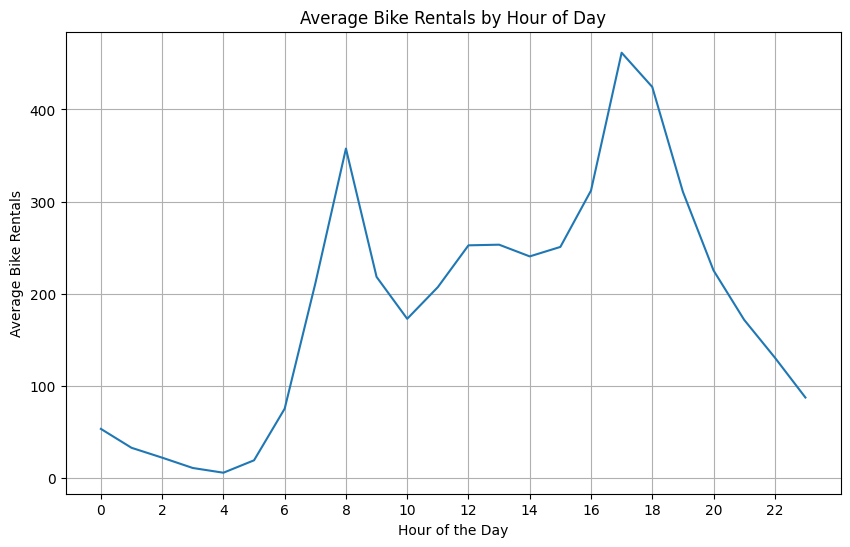

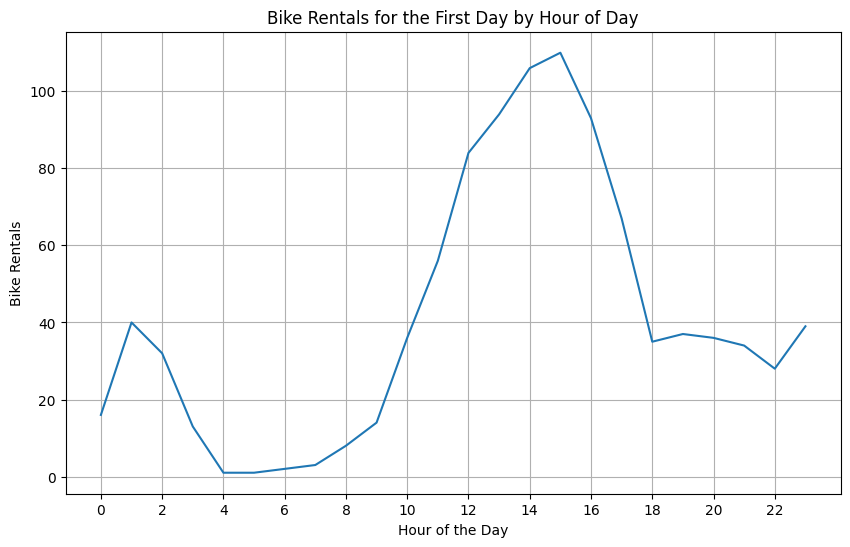

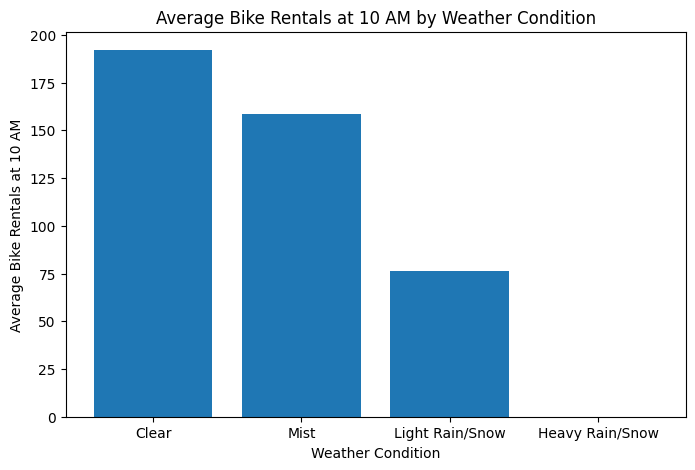

In [17]:
# 자전거 데이터셋 전처리 시각화
import matplotlib.pyplot as plt

# Extract the 'cnt' column (column index 16)
bike_counts = daily_bikes[:, 16, :]

# Calculate the average bike count for each hour of the day across all days
average_hourly_counts = torch.mean(bike_counts, dim=0)

# Create a plot of the average hourly counts
plt.figure(figsize=(10, 6))
plt.plot(range(24), average_hourly_counts.numpy())
plt.xlabel('Hour of the Day')
plt.ylabel('Average Bike Rentals')
plt.title('Average Bike Rentals by Hour of Day')
plt.xticks(range(0, 24, 2)) # Set x-axis ticks every 2 hours
plt.grid(True)
plt.show()

# Example of visualizing bike counts for a specific day
# Let's visualize the bike counts for the first day (index 0)
first_day_counts = daily_bikes[0, 16, :]

plt.figure(figsize=(10, 6))
plt.plot(range(24), first_day_counts.numpy())
plt.xlabel('Hour of the Day')
plt.ylabel('Bike Rentals')
plt.title('Bike Rentals for the First Day by Hour of Day')
plt.xticks(range(0, 24, 2))
plt.grid(True)
plt.show()

# Example of visualizing bike counts based on weather condition for a specific hour (e.g., 10 AM, index 10)
# We need to look at the weather one-hot encoded columns (indices 17-20)
# We will take the average bike count for each weather type at 10 AM across all days

# Find the indices where each weather type is present at 10 AM
weather_type_1_indices = torch.where(daily_bikes[:, 17, 10] == 1)[0]
weather_type_2_indices = torch.where(daily_bikes[:, 18, 10] == 1)[0]
weather_type_3_indices = torch.where(daily_bikes[:, 19, 10] == 1)[0]
weather_type_4_indices = torch.where(daily_bikes[:, 20, 10] == 1)[0]

# Get the bike counts for 10 AM for each weather type
bike_counts_weather_1 = daily_bikes[weather_type_1_indices, 16, 10]
bike_counts_weather_2 = daily_bikes[weather_type_2_indices, 16, 10]
bike_counts_weather_3 = daily_bikes[weather_type_3_indices, 16, 10]
bike_counts_weather_4 = daily_bikes[weather_type_4_indices, 16, 10]

# Calculate the average bike count for each weather type at 10 AM
average_count_weather_1 = torch.mean(bike_counts_weather_1) if len(bike_counts_weather_1) > 0 else 0
average_count_weather_2 = torch.mean(bike_counts_weather_2) if len(bike_counts_weather_2) > 0 else 0
average_count_weather_3 = torch.mean(bike_counts_weather_3) if len(bike_counts_weather_3) > 0 else 0
average_count_weather_4 = torch.mean(bike_counts_weather_4) if len(bike_counts_weather_4) > 0 else 0

weather_labels = ['Clear', 'Mist', 'Light Rain/Snow', 'Heavy Rain/Snow']
average_counts = [average_count_weather_1, average_count_weather_2, average_count_weather_3, average_count_weather_4]

plt.figure(figsize=(8, 5))
plt.bar(weather_labels, average_counts)
plt.xlabel('Weather Condition')
plt.ylabel('Average Bike Rentals at 10 AM')
plt.title('Average Bike Rentals at 10 AM by Weather Condition')
plt.show()
